In [7]:
from typing import TypedDict, List
import random
from langgraph.graph import StateGraph, END, START

In [8]:
class AgentState(TypedDict):
    name: str
    counter: int
    numbers: List[int]
    loop_cnt: int

In [9]:
def greeting_node(state: AgentState) -> AgentState:
    """This node greets the user"""
    state['name'] = f'Hi {state["name"]}!'
    state['counter'] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    """This node generates random numbers and appends to the """
    state['numbers'].append(random.randint(0,10))
    state['counter']+=1
    return state

def looper(state: AgentState) -> AgentState:
    """This node loops loop_cnt times"""
    if state['counter']<state['loop_cnt']:
        print(f'Entering loop {state["counter"]}')
        return 'loop'
    else:
        return 'exit'


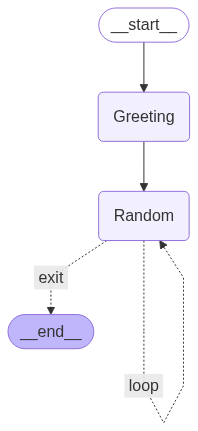

In [10]:
graph = StateGraph(AgentState)
graph.add_node('Greeting',greeting_node)
graph.add_node('Random',random_node)
graph.add_edge(START,'Greeting')
graph.add_edge('Greeting','Random')
graph.add_conditional_edges(
    'Random',
    looper,
    {
        'loop':'Random',
        'exit':END
    }
)
graph.compile()

In [11]:
app = graph.compile()
init_state = AgentState(name='Jayesh', counter=19, numbers=[], loop_cnt=20)
answer = app.invoke(init_state)
print(answer)

Entering loop 1
Entering loop 2
Entering loop 3
Entering loop 4
Entering loop 5
Entering loop 6
Entering loop 7
Entering loop 8
Entering loop 9
Entering loop 10
Entering loop 11
Entering loop 12
Entering loop 13
Entering loop 14
Entering loop 15
Entering loop 16
Entering loop 17
Entering loop 18
Entering loop 19
{'name': 'Hi Jayesh!', 'counter': 20, 'numbers': [8, 3, 0, 9, 10, 8, 1, 2, 5, 7, 8, 5, 10, 5, 5, 2, 10, 7, 8, 3], 'loop_cnt': 20}


In [12]:
len(answer['numbers'])

20